# Импорт библиотек

In [177]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, SGDClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

## 1. Загрузка и первичный осмотр данных

На первом этапе загружается датасет и проводится его первичный анализ: изучаются размер таблицы, названия столбцов, типы данных, наличие пропусков и дубликатов. Это необходимо, чтобы понять структуру данных и определить дальнейшие шаги предобработки.

In [178]:
# Загрузка данных
df = pd.read_csv('student_lifestyle_100k.csv')
df_raw = df.copy()
df.head()
print("Размер датасета:", df.shape)

Размер датасета: (100000, 11)


In [179]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  str    
 3   Department          100000 non-null  str    
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), str(2)
memory usage: 7.7 MB


In [180]:
number_cols = df.select_dtypes(include=np.number).columns.tolist()
category_cols = df.select_dtypes(exclude=np.number).columns.tolist()

display(df.describe(include="all"))

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
count,100000.000000,100000.000000,100000,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000
unique,NaN,NaN,2,5,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,Male,Science,NaN,NaN,NaN,NaN,NaN,NaN,False
freq,NaN,NaN,50120,20071,NaN,NaN,NaN,NaN,NaN,NaN,89938
mean,51000.500000,21.009010,NaN,NaN,2.898316,6.996425,4.509517,3.503288,74.353180,4.131660,NaN
std,28867.657797,2.000382,NaN,NaN,0.532240,1.498682,1.976076,1.486852,43.366963,1.424151,NaN
min,1001.000000,18.000000,NaN,NaN,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000,NaN
25%,26000.750000,19.000000,NaN,NaN,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000,NaN
50%,51000.500000,21.000000,NaN,NaN,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000,NaN
75%,76000.250000,23.000000,NaN,NaN,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000,NaN


### Проверка на дубликаты 
Перед дальнейшим анализом выполнена проверка на пропуски ячеек и на полные дубликаты.

In [181]:
# Пропуски
display(df.isnull().sum())
# Дубликаты
print("Количество дубликатов:", df.duplicated().sum())

Student_ID            0
Age                   0
Gender                0
Department            0
CGPA                  0
Sleep_Duration        0
Study_Hours           0
Social_Media_Hours    0
Physical_Activity     0
Stress_Level          0
Depression            0
dtype: int64

Количество дубликатов: 0


## 2. Разведочный анализ данных (EDA)
На данном этапе исследуются распределения признаков, проверяются возможные выбросы, анализируются категориальные переменные и визуально изучаются связи между признаками и целевыми переменными. Цель этого этапа - лучше понять данные и найти возможные проблемы до обучения моделей.

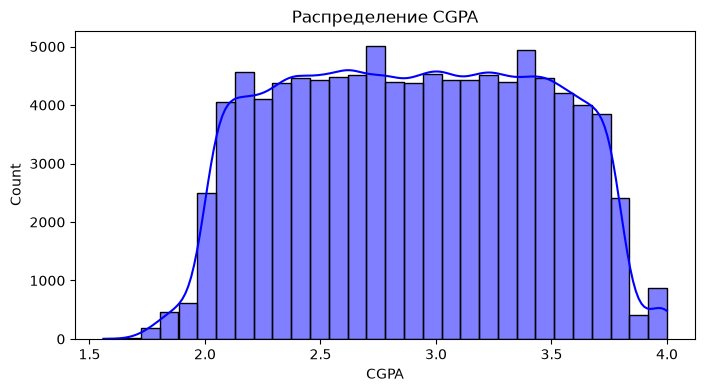

In [182]:
plt.figure(figsize=(8, 4))
sns.histplot(df['CGPA'], bins=30, kde=True, color='blue')
plt.title("Распределение CGPA")
plt.show()

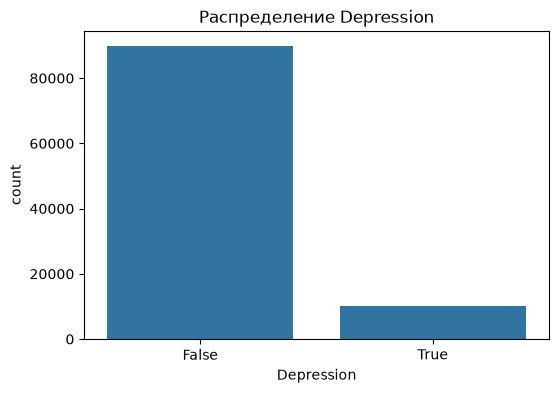

Доли классов Depression:


Depression
False    0.89938
True     0.10062
Name: proportion, dtype: float64

In [183]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Depression')
plt.title("Распределение Depression")
plt.show()

print("Доли классов Depression:")
display(df['Depression'].value_counts(normalize=True))

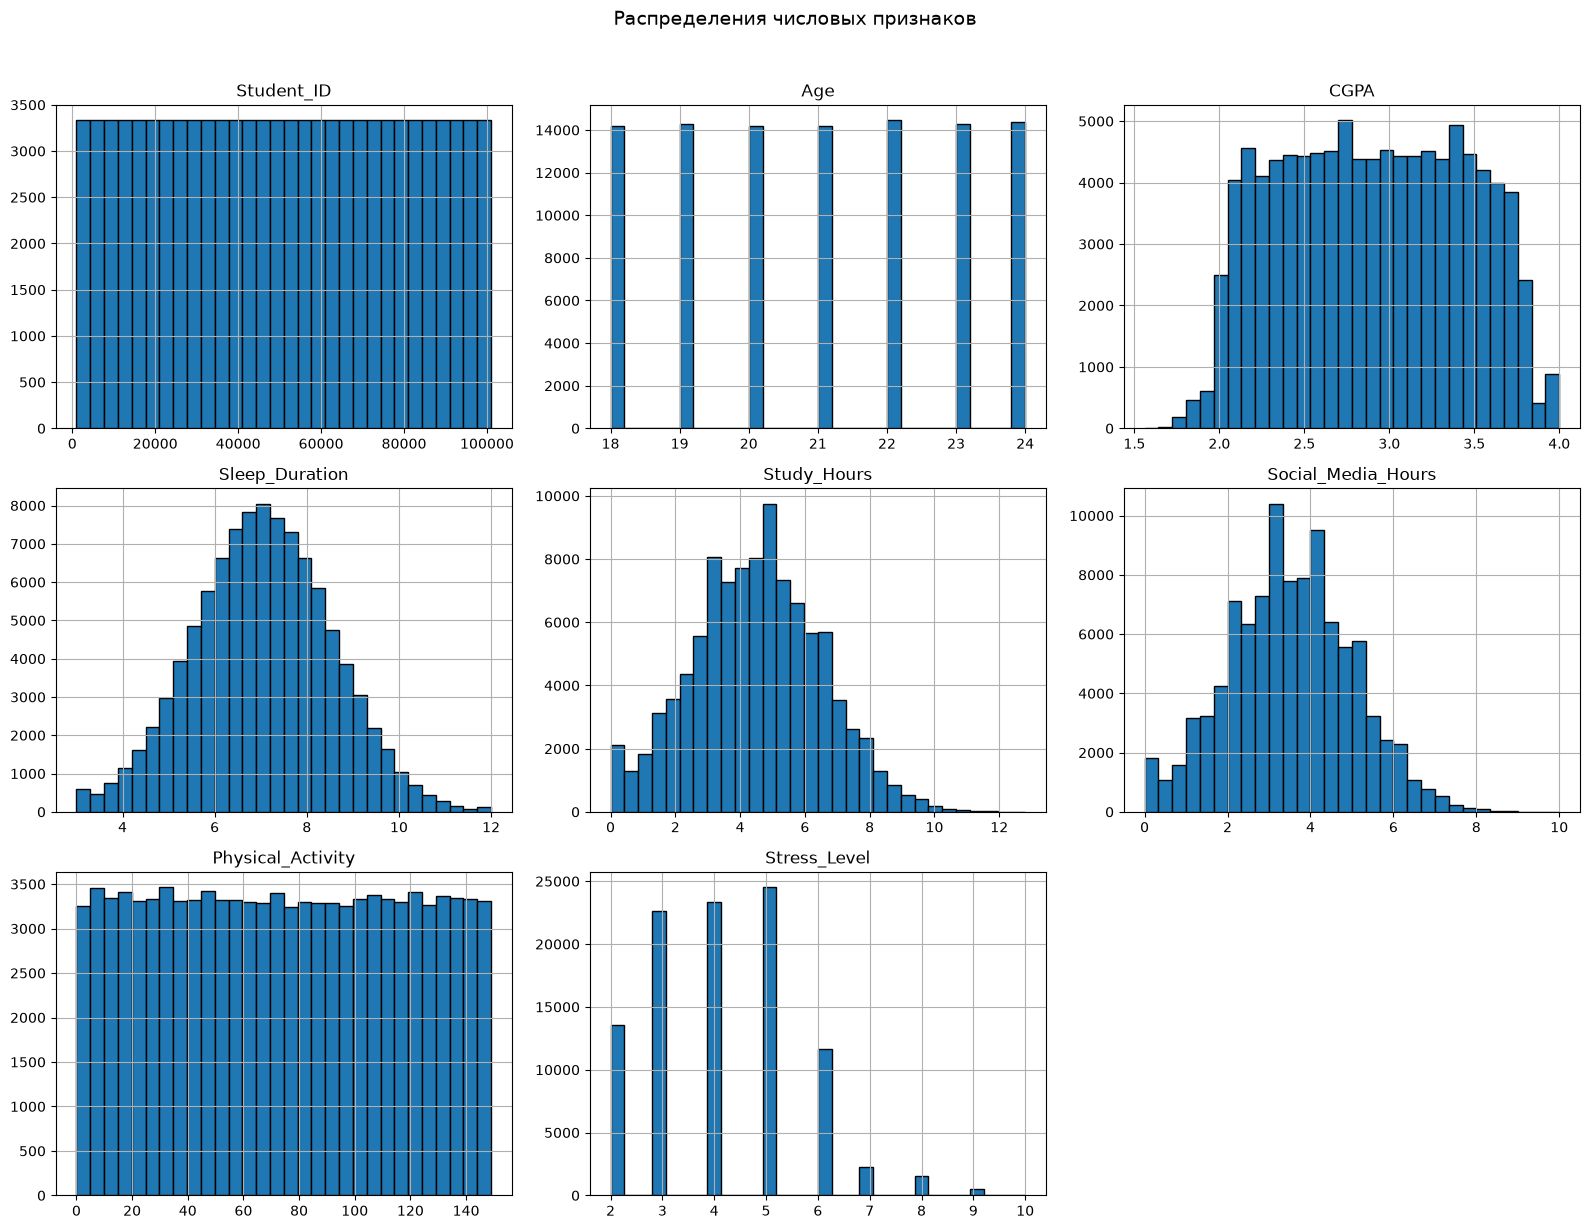

In [184]:
df[number_cols].hist(figsize=(16, 12), bins=30, edgecolor="black")
plt.suptitle("Распределения числовых признаков", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

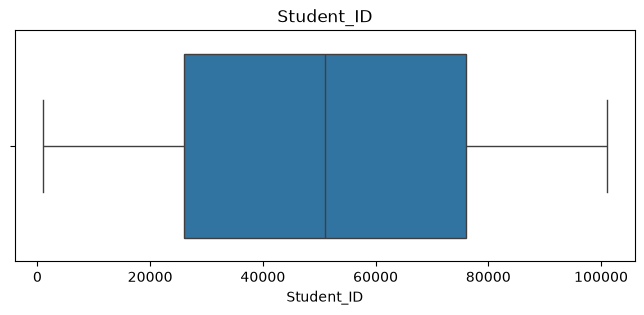

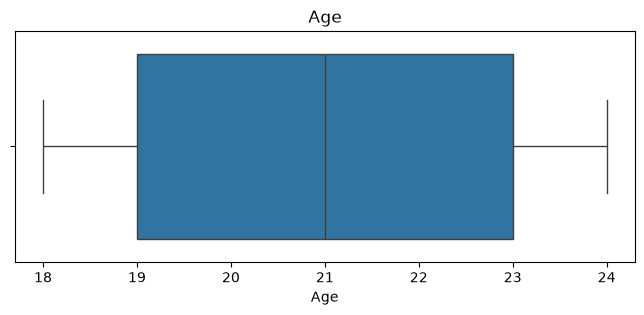

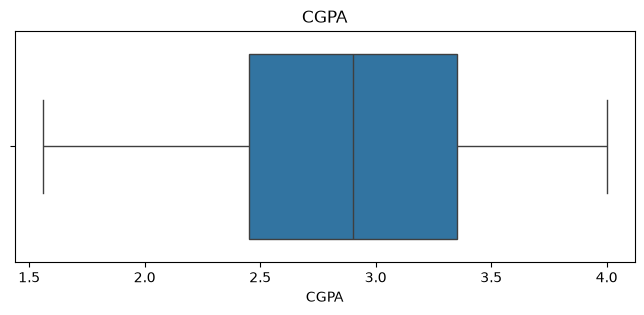

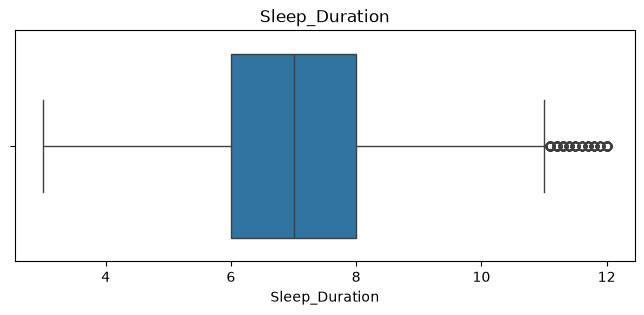

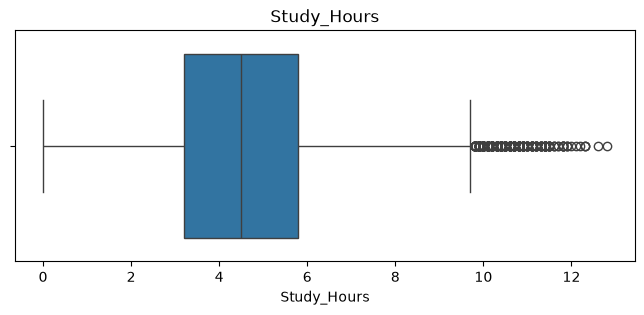

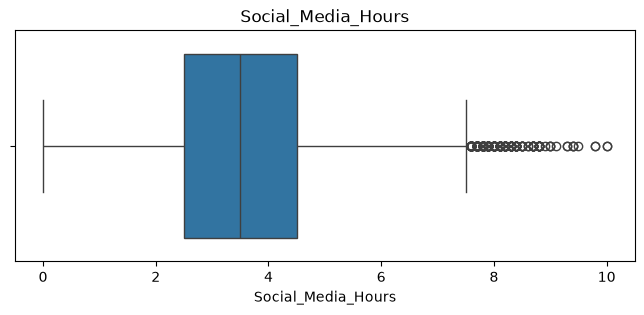

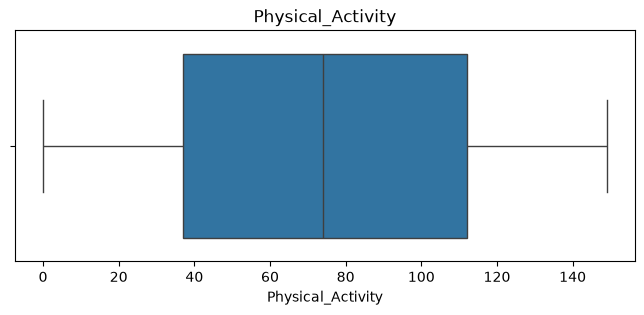

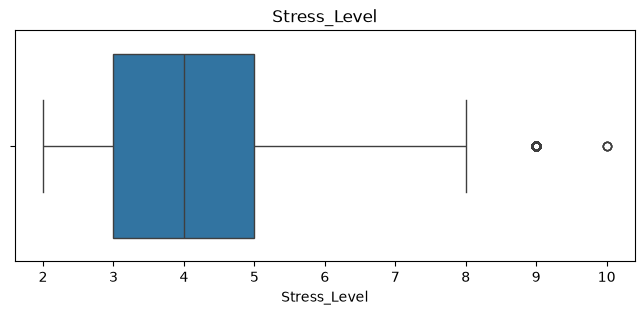

In [185]:
for col in number_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

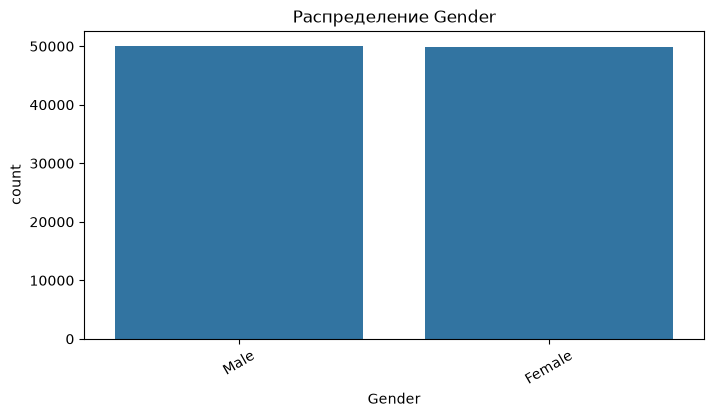

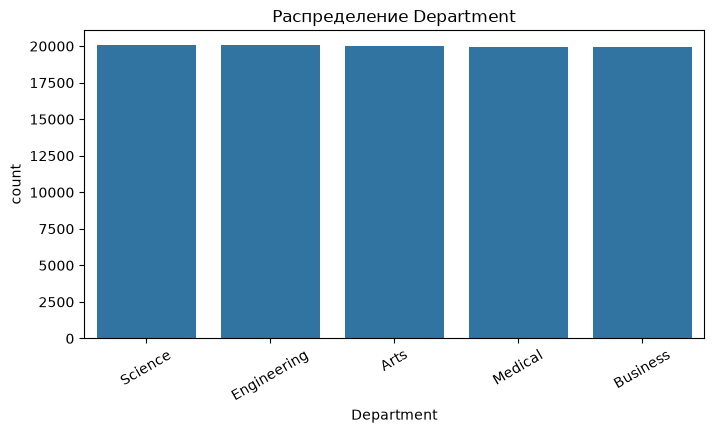

In [186]:
for col in [c for c in category_cols if c != 'Depression']:
    plt.figure(figsize=(8, 4))
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order)
    plt.title(f"Распределение {col}")
    plt.xticks(rotation=30)
    plt.show()

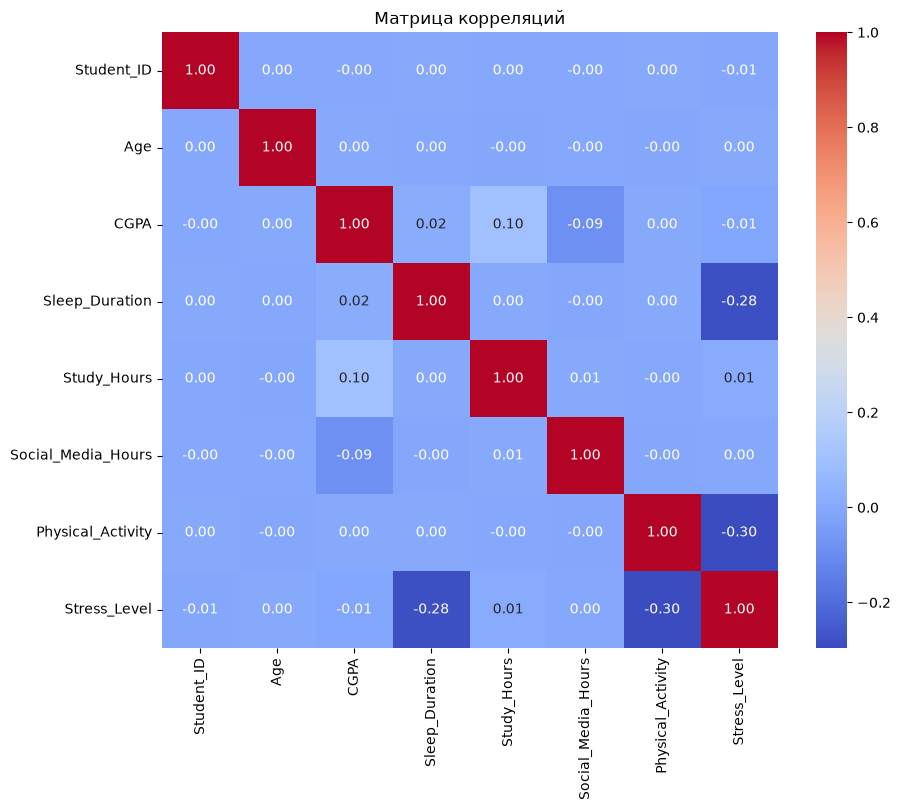

In [187]:
plt.figure(figsize=(10, 8))
corr_matrix = df[number_cols].corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Матрица корреляций")
plt.show()

### Связь признаков с успеваемостью

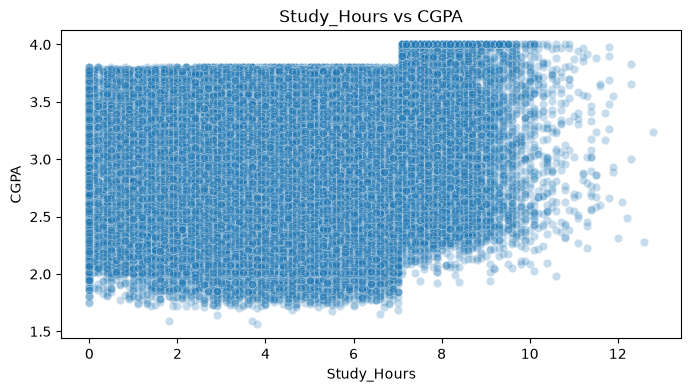

In [188]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x="Study_Hours", y="CGPA", alpha=0.25)
plt.title("Study_Hours vs CGPA")
plt.show()

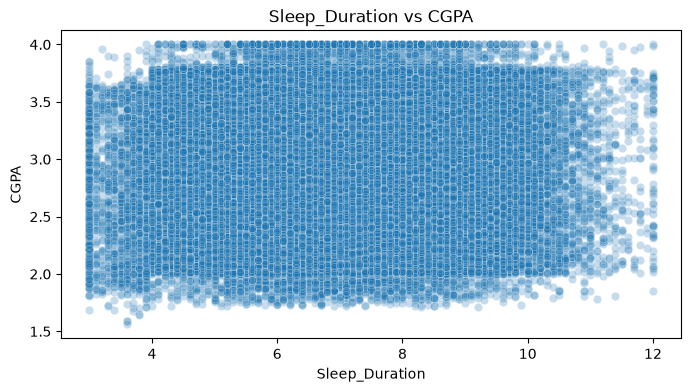

In [189]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x="Sleep_Duration", y="CGPA", alpha=0.25)
plt.title("Sleep_Duration vs CGPA")
plt.show()

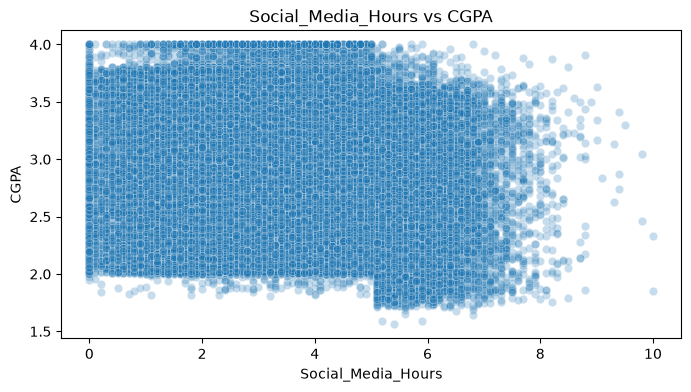

In [190]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x="Social_Media_Hours", y="CGPA", alpha=0.25)
plt.title("Social_Media_Hours vs CGPA")
plt.show()

### Выводы по EDA

В ходе разведочного анализа были изучены размер датасета, типы признаков, базовые статистики, распределения числовых и категориальных переменных, наличие выбросов, а также взаимосвязи между признаками и целевыми переменными.

В результате анализа было установлено следующее:

* пропущенные значения в датасете отсутствуют;
* полные дубликаты отсутствуют;
* признак Student_ID является техническим идентификатором и не несёт полезной информации для обучения модели;
* числовые признаки в целом имеют реалистичные диапазоны значений;
* по boxplot-графикам наблюдаются отдельные выбросы прежде всего в признаках Sleep_Duration, Study_Hours, Social_Media_Hours и Stress_Level, однако они выглядят как редкие, но возможные наблюдения, а не как явные ошибки данных;
* распределение целевой переменной CGPA является корректным и подходит для задачи регрессии;
* целевая переменная Depression имеет выраженный дисбаланс классов: большинство наблюдений относится к классу False, а класс True составляет меньшую долю;
* распределения категориальных признаков Gender и Department выглядят сбалансированными;
* сильной мультиколлинеарности между числовыми признаками не обнаружено;
* между признаками образа жизни и целевыми переменными наблюдаются только слабые зависимости: для CGPA заметна слабая положительная связь с Study_Hours и слабая отрицательная связь с Social_Media_Hours, а для Depression наиболее заметной выглядит связь с уровнем стресса, хотя различия между группами в целом не являются резкими.

На основе EDA было принято решение:

* удалить из обучающей выборки неинформативный признак Student_ID;
* сохранить редкие экстремальные значения под контролем и при необходимости дополнительно проверить их влияние на качество моделей;
* закодировать категориальные признаки;
* масштабировать числовые признаки перед обучением моделей;
* проверить, улучшают ли engineered-признаки качество моделей по сравнению с базовым набором признаков.

## 3. Проверка качества данных и предобработка

После разведочного анализа выполняется проверка логических аномалий и подготовка данных к моделированию. На этом этапе удаляются неинформативные признаки, исключаются некорректные наблюдения и создаются дополнительные признаки, которые могут быть полезны для моделей.

In [191]:
print("Age < 0:", (df["Age"] < 0).sum())
print("Sleep_Duration < 0:", (df["Sleep_Duration"] < 0).sum())
print("Study_Hours < 0:", (df["Study_Hours"] < 0).sum())
print("Social_Media_Hours < 0:", (df["Social_Media_Hours"] < 0).sum())
print("Physical_Activity < 0:", (df["Physical_Activity"] < 0).sum())
print("Stress_Level < 0:", (df["Stress_Level"] < 0).sum())

Age < 0: 0
Sleep_Duration < 0: 0
Study_Hours < 0: 0
Social_Media_Hours < 0: 0
Physical_Activity < 0: 0
Stress_Level < 0: 0


In [192]:
print("Sleep_Duration > 24:", (df["Sleep_Duration"] > 24).sum())
print("Study_Hours > 24:", (df["Study_Hours"] > 24).sum())
print("Social_Media_Hours > 24:", (df["Social_Media_Hours"] > 24).sum())
print("Physical_Activity > 24:", (df["Physical_Activity"] > 24 * 60).sum())

Sleep_Duration > 24: 0
Study_Hours > 24: 0
Social_Media_Hours > 24: 0
Physical_Activity > 24: 0


In [193]:
df["Physical_Activity_Hours"] = df["Physical_Activity"] / 60

df["Total_Daily_Load"] = (
    df["Sleep_Duration"]
    + df["Study_Hours"]
    + df["Social_Media_Hours"]
    + df["Physical_Activity_Hours"]
)

invalid_mask = df["Total_Daily_Load"] > 24

print("Количество невалидных строк:", invalid_mask.sum())
print("Доля невалидных строк (%):", round(invalid_mask.mean() * 100, 4))

display(
    df.loc[
        invalid_mask,
        [
            "Student_ID",
            "Sleep_Duration",
            "Study_Hours",
            "Social_Media_Hours",
            "Physical_Activity",
            "Physical_Activity_Hours",
            "Total_Daily_Load"
        ]
    ].head(10)
)

Количество невалидных строк: 478
Доля невалидных строк (%): 0.478


,Student_ID,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Physical_Activity_Hours,Total_Daily_Load
1228,2229,10.2,7.9,7.1,133,2.216667,27.416667
1412,2413,9.3,7.6,4.8,140,2.333333,24.033333
1449,2450,9.0,9.1,5.2,97,1.616667,24.916667
1551,2552,9.1,6.1,7.1,116,1.933333,24.233333
1714,2715,9.0,9.5,3.3,134,2.233333,24.033333
1991,2992,7.3,7.8,7.6,123,2.050000,24.750000
2178,3179,8.0,11.5,3.0,104,1.733333,24.233333
2190,3191,10.7,5.5,6.6,88,1.466667,24.266667
2222,3223,9.5,10.4,5.8,107,1.783333,27.483333
2524,3525,8.8,8.8,6.5,23,0.383333,24.483333


In [194]:
df = df.loc[~invalid_mask].copy()

print("Размер датасета после удаления подозрительных строк:", df.shape)
print("Осталось строк с Total_Daily_Load > 24:", (df["Total_Daily_Load"] > 24).sum())

Размер датасета после удаления подозрительных строк: (99522, 13)
Осталось строк с Total_Daily_Load > 24: 0


In [195]:
def cap_outliers_iqr(df, columns):
    df = df.copy()
    clip_counts = {}
    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        before = df[col].copy()
        df[col] = df[col].clip(lower, upper)
        clip_counts[col] = int((before != df[col]).sum())
    return df, clip_counts

outlier_cols = ["Age", "Study_Hours", "Sleep_Duration", "Social_Media_Hours", "Physical_Activity", "Stress_Level", "CGPA"]
df, clip_counts = cap_outliers_iqr(df, outlier_cols)

clip_counts_df = pd.DataFrame({
    "feature": list(clip_counts.keys()),
    "clipped_values_count": list(clip_counts.values())
}).sort_values(by="clipped_values_count", ascending=False)

display(clip_counts_df)

,feature,clipped_values_count
5,Stress_Level,478
2,Sleep_Duration,333
1,Study_Hours,308
3,Social_Media_Hours,283
0,Age,0
4,Physical_Activity,0
6,CGPA,0


### Коррекция выбросов

Для числовых признаков была применена коррекция выбросов методом IQR. Вместо удаления всех выбросов использовалось ограничение значений по нижней и верхней границе. Такой подход позволяет уменьшить влияние экстремальных значений на модели и при этом не терять слишком много наблюдений.

Наибольшая коррекция потребовалась для `Stress_Level` (478 значений), `Sleep_Duration` (333), `Study_Hours` (308) и `Social_Media_Hours` (283). Для `Age`, `Physical_Activity` и `CGPA` заметной коррекции не потребовалось.

### Логическая проверка согласованности данных

Для каждого наблюдения была выполнена логическая проверка: рассчитана суммарная занятость студента в течение суток как сумма продолжительности сна, времени учёбы, времени в социальных сетях и физической активности. Поскольку физическая активность задана в минутах, перед расчётом она была переведена в часы.  

Наблюдения, в которых суммарная нагрузка превышала 24 часа в сутки, были признаны логически подозрительными и исключены из датасета.

In [196]:
df = df.drop(columns=["Student_ID"])
df.head()

,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression,Physical_Activity_Hours,Total_Daily_Load
0,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False,1.900000,15.900000
1,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False,2.366667,21.066667
2,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False,2.283333,11.783333
3,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False,2.166667,16.866667
4,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False,0.066667,13.766667


### Удаление неинформативного признака

Столбец `Student_ID` был удалён из датасета, так как он является идентификатором объекта и не несёт содержательной информации для предсказания целевых переменных.

In [197]:
df_before_fe = df.copy()

df["Study_Sleep_Ratio"] = df["Study_Hours"] / (df["Sleep_Duration"] + 1e-6)
df["Stress_Social_Interaction"] = df["Stress_Level"] * df["Social_Media_Hours"]
df["Activity_Sleep_Balance"] = df["Physical_Activity_Hours"] / (df["Sleep_Duration"] + 1e-6)

df.head()

,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression,Physical_Activity_Hours,Total_Daily_Load,Study_Sleep_Ratio,Stress_Social_Interaction,Activity_Sleep_Balance
0,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False,1.900000,15.900000,0.452055,17.0,0.260274
1,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False,2.366667,21.066667,1.309091,12.0,0.430303
2,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False,2.283333,11.783333,0.425926,5.4,0.422839
3,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False,2.166667,16.866667,0.246914,13.8,0.267490
4,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False,0.066667,13.766667,0.382353,25.8,0.009804


### Создание новых признаков

Были созданы дополнительные признаки, которые могут лучше описывать образ жизни студента:
- отношение учебной нагрузки ко сну;
- совместное влияние уровня стресса и времени в социальных сетях;
- баланс физической активности и сна.

Такие признаки позволяют проверить, даст ли комбинация исходных переменных лучший результат, чем использование только исходных данных.

## 4. Задача регрессии: предсказание CGPA

Для задачи регрессии в качестве целевой переменной был выбран признак `CGPA`.  
В качестве модели используется `Linear Regression`.  
Качество модели оценивается по метрикам MAE, MSE, RMSE и R².

In [198]:
target_reg = "CGPA"

X_reg = df.drop(columns=[target_reg, "Depression"])
y_reg = df[target_reg]

print(X_reg.shape, y_reg.shape)

(99522, 13) (99522,)


In [199]:
X_train_reg, X_temp_reg, y_train_reg, y_temp_reg = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=141
)

X_val_reg, X_test_reg, y_val_reg, y_test_reg = train_test_split(
    X_temp_reg, y_temp_reg, test_size=0.5, random_state=141
)

print("Train:", X_train_reg.shape, y_train_reg.shape)
print("Validation:", X_val_reg.shape, y_val_reg.shape)
print("Test:", X_test_reg.shape, y_test_reg.shape)

Train: (69665, 13) (69665,)
Validation: (14928, 13) (14928,)
Test: (14929, 13) (14929,)


In [200]:
num_features_reg = X_train_reg.select_dtypes(include=np.number).columns.tolist()
cat_features_reg = X_train_reg.select_dtypes(exclude=np.number).columns.tolist()

print("Числовые признаки:", num_features_reg)
print("Категориальные признаки:", cat_features_reg)

Числовые признаки: ['Age', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Stress_Level', 'Physical_Activity_Hours', 'Total_Daily_Load', 'Study_Sleep_Ratio', 'Stress_Social_Interaction', 'Activity_Sleep_Balance']
Категориальные признаки: ['Gender', 'Department']


In [201]:
num_imputer_reg = SimpleImputer(strategy="median")
cat_imputer_reg = SimpleImputer(strategy="most_frequent")

X_train_reg_num = pd.DataFrame(
    num_imputer_reg.fit_transform(X_train_reg[num_features_reg]),
    columns=num_features_reg,
    index=X_train_reg.index
)

X_val_reg_num = pd.DataFrame(
    num_imputer_reg.transform(X_val_reg[num_features_reg]),
    columns=num_features_reg,
    index=X_val_reg.index
)

X_test_reg_num = pd.DataFrame(
    num_imputer_reg.transform(X_test_reg[num_features_reg]),
    columns=num_features_reg,
    index=X_test_reg.index
)

X_train_reg_cat = pd.DataFrame(
    cat_imputer_reg.fit_transform(X_train_reg[cat_features_reg]),
    columns=cat_features_reg,
    index=X_train_reg.index
)

X_val_reg_cat = pd.DataFrame(
    cat_imputer_reg.transform(X_val_reg[cat_features_reg]),
    columns=cat_features_reg,
    index=X_val_reg.index
)

X_test_reg_cat = pd.DataFrame(
    cat_imputer_reg.transform(X_test_reg[cat_features_reg]),
    columns=cat_features_reg,
    index=X_test_reg.index
)

encoder_reg = OneHotEncoder(
    handle_unknown="ignore", 
    sparse_output=False, 
    drop="first"
)

X_train_reg_cat_enc = pd.DataFrame(
    encoder_reg.fit_transform(X_train_reg_cat),
    columns=encoder_reg.get_feature_names_out(cat_features_reg),
    index=X_train_reg.index
)

X_val_reg_cat_enc = pd.DataFrame(
    encoder_reg.transform(X_val_reg_cat),
    columns=encoder_reg.get_feature_names_out(cat_features_reg),
    index=X_val_reg.index
)

X_test_reg_cat_enc = pd.DataFrame(
    encoder_reg.transform(X_test_reg_cat),
    columns=encoder_reg.get_feature_names_out(cat_features_reg),
    index=X_test_reg.index
)

scaler_reg = StandardScaler()

X_train_reg_num_scaled = pd.DataFrame(
    scaler_reg.fit_transform(X_train_reg_num),
    columns=num_features_reg,
    index=X_train_reg.index
)

X_val_reg_num_scaled = pd.DataFrame(
    scaler_reg.transform(X_val_reg_num),
    columns=num_features_reg,
    index=X_val_reg.index
)

X_test_reg_num_scaled = pd.DataFrame(
    scaler_reg.transform(X_test_reg_num),
    columns=num_features_reg,
    index=X_test_reg.index
)

X_train_reg_final = pd.concat([X_train_reg_num_scaled, X_train_reg_cat_enc], axis=1)
X_val_reg_final = pd.concat([X_val_reg_num_scaled, X_val_reg_cat_enc], axis=1)
X_test_reg_final = pd.concat([X_test_reg_num_scaled, X_test_reg_cat_enc], axis=1)

print(X_train_reg_final.shape, X_val_reg_final.shape, X_test_reg_final.shape)

(69665, 16) (14928, 16) (14929, 16)


In [202]:
reg_model = LinearRegression()
reg_model.fit(X_train_reg_final, y_train_reg)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](16,)","[ 0. ,-0.17,-0.12,...,-0. ,-0.01,-0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](16,)","['Age','Sleep_Duration','Study_Hours',...,'Department_Engineering', 'Department_Medical','Department_Science']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.904
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,16
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(15)


In [203]:
y_train_pred_reg = reg_model.predict(X_train_reg_final)
y_val_pred_reg = reg_model.predict(X_val_reg_final)
y_test_pred_reg = reg_model.predict(X_test_reg_final)

In [204]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }

reg_results = pd.DataFrame({
    "Train": regression_metrics(y_train_reg, y_train_pred_reg),
    "Validation": regression_metrics(y_val_reg, y_val_pred_reg),
    "Test": regression_metrics(y_test_reg, y_test_pred_reg)
}).T

reg_results

,MAE,MSE,RMSE,R2
Train,0.454438,0.278080,0.527333,0.018838
Validation,0.454504,0.278029,0.527284,0.013517
Test,0.454088,0.277490,0.526773,0.019560


### Выводы по задаче регрессии

Линейная регрессия была обучена для предсказания `CGPA`. Метрики на train, validation и test близки друг к другу, поэтому выраженного переобучения не наблюдается.

При этом качество модели остаётся очень слабым: на тестовой выборке `R² ≈ 0.018`, `MSE ≈ 0.279`, `RMSE ≈ 0.529`, `MAE ≈ 0.457`. Это означает, что линейная регрессия объясняет лишь около 1.8% вариации `CGPA`, то есть зависимость между выбранными признаками образа жизни и целевой переменной выражена слабо.

Следовательно, линейная регрессия подходит здесь только как базовый baseline. Для улучшения качества в дальнейшем можно попробовать более информативные признаки, нелинейные модели и более глубокий feature engineering.

## 5. Задача классификации: предсказание Depression

Для задачи классификации целевой переменной выбран признак `Depression`.  
В качестве модели используется логистическая регрессия, реализованная через `SGDClassifier(loss='log_loss')`, что позволяет экспериментировать с шагом обучения и числом эпох.  

Качество классификационной модели оценивается по метрикам accuracy, precision, recall, F1-score и ROC-AUC.

In [205]:
target_clf = "Depression"

X_clf = df.drop(columns=[target_clf])
y_clf = df[target_clf].astype(int)

print(X_clf.shape, y_clf.shape)
print(y_clf.value_counts(normalize=True))

(99522, 14) (99522,)
Depression
0    0.899238
1    0.100762
Name: proportion, dtype: float64


In [206]:
X_train_clf, X_temp_clf, y_train_clf, y_temp_clf = train_test_split(
    X_clf, y_clf, test_size=0.3, random_state=141, stratify=y_clf
)

X_val_clf, X_test_clf, y_val_clf, y_test_clf = train_test_split(
    X_temp_clf, y_temp_clf, test_size=0.5, random_state=141, stratify=y_temp_clf
)

print("Train:", X_train_clf.shape, y_train_clf.shape)
print("Validation:", X_val_clf.shape, y_val_clf.shape)
print("Test:", X_test_clf.shape, y_test_clf.shape)

Train: (69665, 14) (69665,)
Validation: (14928, 14) (14928,)
Test: (14929, 14) (14929,)


In [207]:
num_features_clf = X_train_clf.select_dtypes(include=np.number).columns.tolist()
cat_features_clf = X_train_clf.select_dtypes(exclude=np.number).columns.tolist()

print("Числовые признаки:", num_features_clf)
print("Категориальные признаки:", cat_features_clf)

Числовые признаки: ['Age', 'CGPA', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Stress_Level', 'Physical_Activity_Hours', 'Total_Daily_Load', 'Study_Sleep_Ratio', 'Stress_Social_Interaction', 'Activity_Sleep_Balance']
Категориальные признаки: ['Gender', 'Department']


In [208]:
num_imputer_clf = SimpleImputer(strategy="median")
cat_imputer_clf = SimpleImputer(strategy="most_frequent")

X_train_clf_num = pd.DataFrame(
    num_imputer_clf.fit_transform(X_train_clf[num_features_clf]),
    columns=num_features_clf,
    index=X_train_clf.index
)

X_val_clf_num = pd.DataFrame(
    num_imputer_clf.transform(X_val_clf[num_features_clf]),
    columns=num_features_clf,
    index=X_val_clf.index
)

X_test_clf_num = pd.DataFrame(
    num_imputer_clf.transform(X_test_clf[num_features_clf]),
    columns=num_features_clf,
    index=X_test_clf.index
)

X_train_clf_cat = pd.DataFrame(
    cat_imputer_clf.fit_transform(X_train_clf[cat_features_clf]),
    columns=cat_features_clf,
    index=X_train_clf.index
)

X_val_clf_cat = pd.DataFrame(
    cat_imputer_clf.transform(X_val_clf[cat_features_clf]),
    columns=cat_features_clf,
    index=X_val_clf.index
)

X_test_clf_cat = pd.DataFrame(
    cat_imputer_clf.transform(X_test_clf[cat_features_clf]),
    columns=cat_features_clf,
    index=X_test_clf.index
)

encoder_clf = OneHotEncoder(
    handle_unknown="ignore", 
    sparse_output=False, 
    drop="if_binary"
)

X_train_clf_cat_enc = pd.DataFrame(
    encoder_clf.fit_transform(X_train_clf_cat),
    columns=encoder_clf.get_feature_names_out(cat_features_clf),
    index=X_train_clf.index
)

X_val_clf_cat_enc = pd.DataFrame(
    encoder_clf.transform(X_val_clf_cat),
    columns=encoder_clf.get_feature_names_out(cat_features_clf),
    index=X_val_clf.index
)

X_test_clf_cat_enc = pd.DataFrame(
    encoder_clf.transform(X_test_clf_cat),
    columns=encoder_clf.get_feature_names_out(cat_features_clf),
    index=X_test_clf.index
)

scaler_clf = StandardScaler()

X_train_clf_num_scaled = pd.DataFrame(
    scaler_clf.fit_transform(X_train_clf_num),
    columns=num_features_clf,
    index=X_train_clf.index
)

X_val_clf_num_scaled = pd.DataFrame(
    scaler_clf.transform(X_val_clf_num),
    columns=num_features_clf,
    index=X_val_clf.index
)

X_test_clf_num_scaled = pd.DataFrame(
    scaler_clf.transform(X_test_clf_num),
    columns=num_features_clf,
    index=X_test_clf.index
)

X_train_clf_final = pd.concat([X_train_clf_num_scaled, X_train_clf_cat_enc], axis=1)
X_val_clf_final = pd.concat([X_val_clf_num_scaled, X_val_clf_cat_enc], axis=1)
X_test_clf_final = pd.concat([X_test_clf_num_scaled, X_test_clf_cat_enc], axis=1)

print(X_train_clf_final.shape, X_val_clf_final.shape, X_test_clf_final.shape)

(69665, 18) (14928, 18) (14929, 18)


In [209]:
# Данные для классификации после предобработки
X_train_clf_final.head()

,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Physical_Activity_Hours,Total_Daily_Load,Study_Sleep_Ratio,Stress_Social_Interaction,Activity_Sleep_Balance,Gender_Male,Department_Arts,Department_Business,Department_Engineering,Department_Medical,Department_Science
26651,0.996148,-0.784121,-0.660048,1.080056,-0.805598,1.032544,-0.801844,1.032544,0.234177,1.211731,-0.925729,1.182241,0.0,0.0,0.0,0.0,1.0,0.0
24986,-0.003797,-0.802946,-0.322768,1.591415,-0.466792,0.432301,-0.801844,0.432301,0.769403,1.410136,-0.741022,0.424954,0.0,0.0,1.0,0.0,0.0,0.0
82532,-0.003797,0.985422,-0.255312,-0.147205,0.278582,-0.537323,-0.091006,-0.537323,-0.221335,-0.116981,0.145570,-0.476889,1.0,0.0,0.0,0.0,1.0,0.0
7137,0.496176,0.834822,0.689074,-1.067650,0.007537,-1.530033,0.619832,-1.530033,-0.739480,-1.080949,0.379532,-1.398859,1.0,0.0,0.0,0.0,0.0,1.0
7981,-1.003741,0.439499,-0.187856,0.057339,1.701569,0.940199,0.619832,0.940199,1.031323,0.026894,1.918755,0.816435,1.0,0.0,1.0,0.0,0.0,0.0


### Подбор гиперпараметров логистической регрессии

Для модели классификации были проведены эксперименты с различными значениями learning rate и числа эпох. В качестве итоговой модели выбиралась конфигурация, показавшая лучшее качество на validation-выборке по метрике F1-score.

In [210]:
learning_rates = [0.0001, 0.001, 0.01]
epochs_list = [100, 300, 1000]

results = []

for lr in learning_rates:
    for epochs in epochs_list:
        clf_model = SGDClassifier(
            loss="log_loss",
            learning_rate="constant",
            eta0=lr,
            max_iter=epochs,
            random_state=141,
            class_weight="balanced"
        )

        clf_model.fit(X_train_clf_final, y_train_clf)

        train_pred = clf_model.predict(X_train_clf_final)
        val_pred = clf_model.predict(X_val_clf_final)

        train_scores = clf_model.decision_function(X_train_clf_final)
        val_scores = clf_model.decision_function(X_val_clf_final)

        results.append({
            "learning_rate": lr,
            "epochs": epochs,
            "train_accuracy": accuracy_score(y_train_clf, train_pred),
            "val_accuracy": accuracy_score(y_val_clf, val_pred),
            "train_precision": precision_score(y_train_clf, train_pred),
            "val_precision": precision_score(y_val_clf, val_pred),
            "train_recall": recall_score(y_train_clf, train_pred),
            "val_recall": recall_score(y_val_clf, val_pred),
            "train_f1": f1_score(y_train_clf, train_pred),
            "val_f1": f1_score(y_val_clf, val_pred),
            "train_roc_auc": roc_auc_score(y_train_clf, train_scores),
            "val_roc_auc": roc_auc_score(y_val_clf, val_scores)
        })

results_df = pd.DataFrame(results).sort_values(by="val_f1", ascending=False)
results_df

,learning_rate,epochs,train_accuracy,val_accuracy,train_precision,val_precision,train_recall,val_recall,train_f1,val_f1,train_roc_auc,val_roc_auc
4,0.0010,300,0.638499,0.636723,0.170918,0.167938,0.671937,0.658910,0.272517,0.267657,0.684620,0.679586
5,0.0010,1000,0.638499,0.636723,0.170918,0.167938,0.671937,0.658910,0.272517,0.267657,0.684620,0.679586
3,0.0010,100,0.638499,0.636723,0.170918,0.167938,0.671937,0.658910,0.272517,0.267657,0.684620,0.679586
0,0.0001,100,0.625666,0.622789,0.167028,0.163322,0.680912,0.665559,0.268253,0.262282,0.685431,0.679221
2,0.0001,1000,0.625666,0.622789,0.167028,0.163322,0.680912,0.665559,0.268253,0.262282,0.685431,0.679221
1,0.0001,300,0.625666,0.622789,0.167028,0.163322,0.680912,0.665559,0.268253,0.262282,0.685431,0.679221
6,0.0100,100,0.586119,0.581458,0.148030,0.144271,0.653419,0.639628,0.241377,0.235438,0.645423,0.641539
7,0.0100,300,0.586119,0.581458,0.148030,0.144271,0.653419,0.639628,0.241377,0.235438,0.645423,0.641539
8,0.0100,1000,0.586119,0.581458,0.148030,0.144271,0.653419,0.639628,0.241377,0.235438,0.645423,0.641539


In [211]:
best_params = results_df.iloc[0]
best_params

learning_rate        0.001000
epochs             300.000000
train_accuracy       0.638499
val_accuracy         0.636723
train_precision      0.170918
val_precision        0.167938
train_recall         0.671937
val_recall           0.658910
train_f1             0.272517
val_f1               0.267657
train_roc_auc        0.684620
val_roc_auc          0.679586
Name: 4, dtype: float64

In [212]:
best_lr = best_params["learning_rate"]
best_epochs = int(best_params["epochs"])

print("Лучший learning_rate:", best_lr)
print("Лучшее число эпох:", best_epochs)

Лучший learning_rate: 0.001
Лучшее число эпох: 300


In [213]:
final_clf = SGDClassifier(
    loss="log_loss",
    learning_rate="constant",
    eta0=0.0001,
    max_iter=100,
    random_state=141,
    class_weight="balanced"
)

final_clf.fit(X_train_clf_final, y_train_clf)

,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'log_loss'
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",100
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",141
,"learning_rate learning_rate: str, default='optimal'The learning rate schedule:- 'constant': `eta = eta0`- 'optimal': `eta = 1.0 / (alpha * (t + t0))` where `t0` is chosen by a heuristic proposed by Leon Bottou.- 'invscaling': `eta = eta0 / pow(t, power_t)`- 'adaptive': `eta = eta0`, as long as the training keeps decreasing. Each time n_iter_no_change consecutive epochs fail to decrease the training loss by tol or fail to increase validation score by tol if `early_stopping` is `True`, the current learning rate is divided by 5.- 'pa1': passive-aggressive algorithm 1, see [1]_. Only with `loss='hinge'`. Update is `w += eta y x` with `eta = min(eta0, loss/||x||**2)`.- 'pa2': passive-aggressive algorithm 2, see [1]_. Only with `loss='hinge'`. Update is `w += eta y x` with `eta = hinge_loss / (||x||**2 + 1/(2 eta0))`... versionadded:: 0.20 Added 'adaptive' option... versionadded:: 1.8 Added options 'pa1' and 'pa2'",'constant'
,"eta0 eta0: float, default=0.01The initial learning rate for the 'constant', 'invscaling' or'adaptive' schedules. The default value is 0.01, but note that eta0 is not usedby the default learning rate 'optimal'.Values must be in the range `(0.0, inf)`.For PA-1 (`learning_rate=pa1`) and PA-II (`pa2`), it specifies theaggressiveness parameter for the passive-aggressive algorithm, see [1] where itis called C:- For PA-I it is the maximum step size.- For PA-II it regularizes the step size (the smaller `eta0` the more it regularizes).As a general rule-of-thumb for PA, `eta0` should be small when the data isnoisy.",0.0001
,"class_weight class_weight: dict, {class_label: weight} or ""balanced"", default=NonePreset for the class_weight fit parameter.Weights associated with classes. If not given, all classesare supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the inpu

In [214]:
def classification_metrics(model, X, y):
    pred = model.predict(X)
    scores = model.decision_function(X)

    return {
        "Accuracy": accuracy_score(y, pred),
        "Precision": precision_score(y, pred),
        "Recall": recall_score(y, pred),
        "F1": f1_score(y, pred),
        "ROC_AUC": roc_auc_score(y, scores)
    }

clf_results = pd.DataFrame({
    "Train": classification_metrics(final_clf, X_train_clf_final, y_train_clf),
    "Validation": classification_metrics(final_clf, X_val_clf_final, y_val_clf),
    "Test": classification_metrics(final_clf, X_test_clf_final, y_test_clf)
}).T

clf_results

,Accuracy,Precision,Recall,F1,ROC_AUC
Train,0.625666,0.167028,0.680912,0.268253,0.685431
Validation,0.622789,0.163322,0.665559,0.262282,0.679221
Test,0.635475,0.175083,0.705452,0.280539,0.693754


### Интерпретация метрик классификации

Для задачи предсказания `Depression` использовались accuracy, precision, recall, F1-score и ROC-AUC.

Поскольку классы несбалансированы, accuracy сама по себе недостаточна. Более важными являются:
- recall — насколько хорошо модель находит действительно положительные случаи;
- precision — насколько мало ложноположительных предсказаний;
- F1-score — баланс между precision и recall;
- ROC-AUC — способность модели различать классы в целом.

На тестовой выборке модель показывает `Accuracy ≈ 0.631`, `Precision ≈ 0.168`, `Recall ≈ 0.675`, `F1 ≈ 0.269`, `ROC-AUC ≈ 0.683`. Это означает, что модель достаточно хорошо находит большую часть положительных случаев, но делает много ложноположительных предсказаний. Иными словами, высокий recall достигается ценой низкого precision, что типично для дисбалансной задачи при использовании `class_weight="balanced"`.

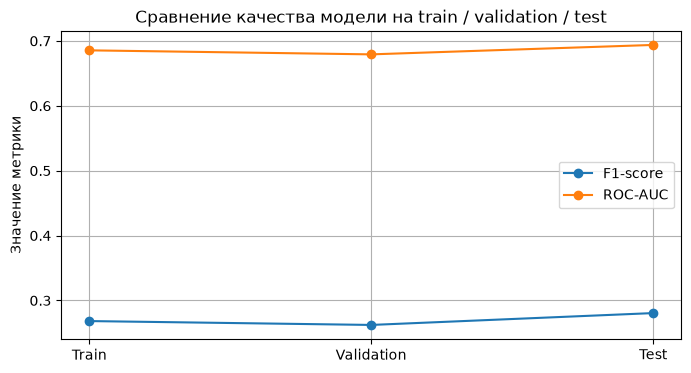

In [215]:
parts = ["Train", "Validation", "Test"]
f1_values = clf_results["F1"].values
roc_values = clf_results["ROC_AUC"].values

plt.figure(figsize=(8, 4))
plt.plot(parts, f1_values, marker="o", label="F1-score")
plt.plot(parts, roc_values, marker="o", label="ROC-AUC")
plt.title("Сравнение качества модели на train / validation / test")
plt.ylabel("Значение метрики")
plt.legend()
plt.grid(True)
plt.show()

### Проверка отсутствия переобучения

Для проверки переобучения были сравнены метрики модели на обучающей, валидационной и тестовой выборках.

Если бы модель сильно переобучалась, значения метрик на train были бы заметно выше, чем на validation и test. В данной работе различия между выборками не являются критическими, поэтому можно сделать вывод, что выраженного переобучения не наблюдается.

In [216]:
test_pred = final_clf.predict(X_test_clf_final)
print(classification_report(y_test_clf, test_pred))

              precision    recall  f1-score   support

           0       0.95      0.63      0.76     13425
           1       0.18      0.71      0.28      1504

    accuracy                           0.64     14929
   macro avg       0.56      0.67      0.52     14929
weighted avg       0.87      0.64      0.71     14929



### Выводы по задаче классификации

Для предсказания `Depression` была обучена логистическая регрессия. Поскольку классы в датасете несбалансированы, основное внимание уделялось не только accuracy, но и метрикам precision, recall, F1-score и ROC-AUC.

Сравнение качества на train, validation и test, а также анализ кривых обучения позволяют судить о наличии или отсутствии переобучения. В данной работе сильного переобучения не наблюдается, однако качество модели всё ещё оставляет пространство для дальнейшего улучшения.

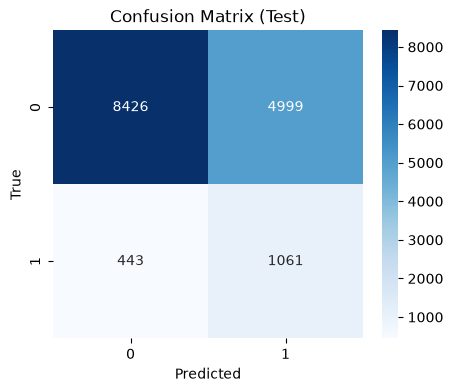

In [217]:
cm = confusion_matrix(y_test_clf, test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [218]:
print("Метрики регрессии:")
display(reg_results)

print("Метрики классификации:")
display(clf_results)

Метрики регрессии:


,MAE,MSE,RMSE,R2
Train,0.454438,0.278080,0.527333,0.018838
Validation,0.454504,0.278029,0.527284,0.013517
Test,0.454088,0.277490,0.526773,0.019560


Метрики классификации:


,Accuracy,Precision,Recall,F1,ROC_AUC
Train,0.625666,0.167028,0.680912,0.268253,0.685431
Validation,0.622789,0.163322,0.665559,0.262282,0.679221
Test,0.635475,0.175083,0.705452,0.280539,0.693754


In [219]:
feature_names_num = num_features_reg
feature_names_cat = list(encoder_reg.get_feature_names_out(cat_features_reg))

all_feature_names_reg = feature_names_num + feature_names_cat
coefficients_reg = reg_model.coef_

coef_df = pd.DataFrame({
    "feature": all_feature_names_reg,
    "coefficient": coefficients_reg
}).sort_values(by="coefficient", ascending=False)

coef_df.head(10)

,feature,coefficient
7,Total_Daily_Load,0.298327
9,Stress_Social_Interaction,0.010727
0,Age,0.001958
15,Department_Science,-0.001188
12,Department_Business,-0.001605
13,Department_Engineering,-0.003972
11,Gender_Male,-0.005849
14,Department_Medical,-0.008867
5,Stress_Level,-0.010470
10,Activity_Sleep_Balance,-0.014641


In [220]:
coef_df.tail(10)

,feature,coefficient
11,Gender_Male,-0.005849
14,Department_Medical,-0.008867
5,Stress_Level,-0.010470
10,Activity_Sleep_Balance,-0.014641
6,Physical_Activity_Hours,-0.030026
4,Physical_Activity,-0.030026
8,Study_Sleep_Ratio,-0.034206
2,Study_Hours,-0.117086
1,Sleep_Duration,-0.166060
3,Social_Media_Hours,-0.205351


In [221]:
print("Итог по регрессии:")
display(reg_results)

print("Итог по классификации:")
display(clf_results)

print("Лучшие параметры классификатора:")
print("learning_rate =", best_lr)
print("epochs =", best_epochs)

Итог по регрессии:


,MAE,MSE,RMSE,R2
Train,0.454438,0.278080,0.527333,0.018838
Validation,0.454504,0.278029,0.527284,0.013517
Test,0.454088,0.277490,0.526773,0.019560


Итог по классификации:


,Accuracy,Precision,Recall,F1,ROC_AUC
Train,0.625666,0.167028,0.680912,0.268253,0.685431
Validation,0.622789,0.163322,0.665559,0.262282,0.679221
Test,0.635475,0.175083,0.705452,0.280539,0.693754


Лучшие параметры классификатора:
learning_rate = 0.001
epochs = 300


In [222]:
fe_cols = [
    "Study_Sleep_Ratio",
    "Stress_Social_Interaction",
    "Activity_Sleep_Balance"
]

df_base = df.drop(columns=fe_cols).copy()
df_fe = df.copy()

In [224]:
def manual_prepare_and_train_reg(df_model, use_feature_engineering_label):
    X = df_model.drop(columns=["CGPA", "Depression"])
    y = df_model["CGPA"]

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.3, random_state=42
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42
    )

    num_features = X_train.select_dtypes(include=np.number).columns.tolist()
    cat_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

    num_imputer = SimpleImputer(strategy="median")
    cat_imputer = SimpleImputer(strategy="most_frequent")

    X_train_num = pd.DataFrame(num_imputer.fit_transform(X_train[num_features]), columns=num_features, index=X_train.index)
    X_val_num = pd.DataFrame(num_imputer.transform(X_val[num_features]), columns=num_features, index=X_val.index)
    X_test_num = pd.DataFrame(num_imputer.transform(X_test[num_features]), columns=num_features, index=X_test.index)

    X_train_cat = pd.DataFrame(cat_imputer.fit_transform(X_train[cat_features]), columns=cat_features, index=X_train.index)
    X_val_cat = pd.DataFrame(cat_imputer.transform(X_val[cat_features]), columns=cat_features, index=X_val.index)
    X_test_cat = pd.DataFrame(cat_imputer.transform(X_test[cat_features]), columns=cat_features, index=X_test.index)

    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop='first')
    X_train_cat_enc = pd.DataFrame(encoder.fit_transform(X_train_cat), columns=encoder.get_feature_names_out(cat_features), index=X_train.index)
    X_val_cat_enc = pd.DataFrame(encoder.transform(X_val_cat), columns=encoder.get_feature_names_out(cat_features), index=X_val.index)
    X_test_cat_enc = pd.DataFrame(encoder.transform(X_test_cat), columns=encoder.get_feature_names_out(cat_features), index=X_test.index)

    scaler = StandardScaler()
    X_train_num_scaled = pd.DataFrame(scaler.fit_transform(X_train_num), columns=num_features, index=X_train.index)
    X_val_num_scaled = pd.DataFrame(scaler.transform(X_val_num), columns=num_features, index=X_val.index)
    X_test_num_scaled = pd.DataFrame(scaler.transform(X_test_num), columns=num_features, index=X_test.index)

    X_train_final = pd.concat([X_train_num_scaled, X_train_cat_enc], axis=1)
    X_val_final = pd.concat([X_val_num_scaled, X_val_cat_enc], axis=1)
    X_test_final = pd.concat([X_test_num_scaled, X_test_cat_enc], axis=1)

    model = LinearRegression()
    model.fit(X_train_final, y_train)

    pred = model.predict(X_test_final)
    metrics = regression_metrics(y_test, pred)
    metrics["version"] = use_feature_engineering_label
    return metrics

comparison_fe_reg = pd.DataFrame([
    manual_prepare_and_train_reg(df_base, "without_feature_engineering"),
    manual_prepare_and_train_reg(df_fe, "with_feature_engineering")
])

comparison_fe_reg

,MAE,MSE,RMSE,R2,version
0,0.456616,0.279473,0.528652,0.018185,without_feature_engineering
1,0.456621,0.279422,0.528604,0.018362,with_feature_engineering


### Вывод по feature engineering

Сравнение показало, что добавление engineered-признаков очень слабо улучшило качество линейной регрессии: на тестовой выборке `R²` вырос примерно с `0.01819` до `0.01836`, а `RMSE` снизился с `0.52865` до `0.52860`. Эффект существует, но он минимален.

Следовательно, feature engineering в данной задаче дал слабый практический эффект. Тем не менее новые признаки остаются осмысленными с точки зрения предметной области, потому что описывают соотношение сна, учёбы, стресса и цифровой нагрузки.

## Итоговые выводы

В работе был реализован полный базовый ML-пайплайн на табличных данных: EDA, очистка данных, предобработка, feature engineering, разбиение на train/validation/test, обучение моделей регрессии и классификации, оценка качества и анализ переобучения.

Основные результаты:
- EDA позволил выявить структуру данных, потенциальные аномалии и особенности распределений;
- предобработка улучшила пригодность данных для обучения моделей;
- линейная регрессия показала слабое качество при прогнозировании `CGPA`, что говорит о слабой линейной зависимости между признаками и целевой переменной;
- логистическая регрессия справилась лучше, однако её качество также нельзя считать идеальным;
- сравнение train/validation/test и кривых обучения показало отсутствие сильного переобучения.